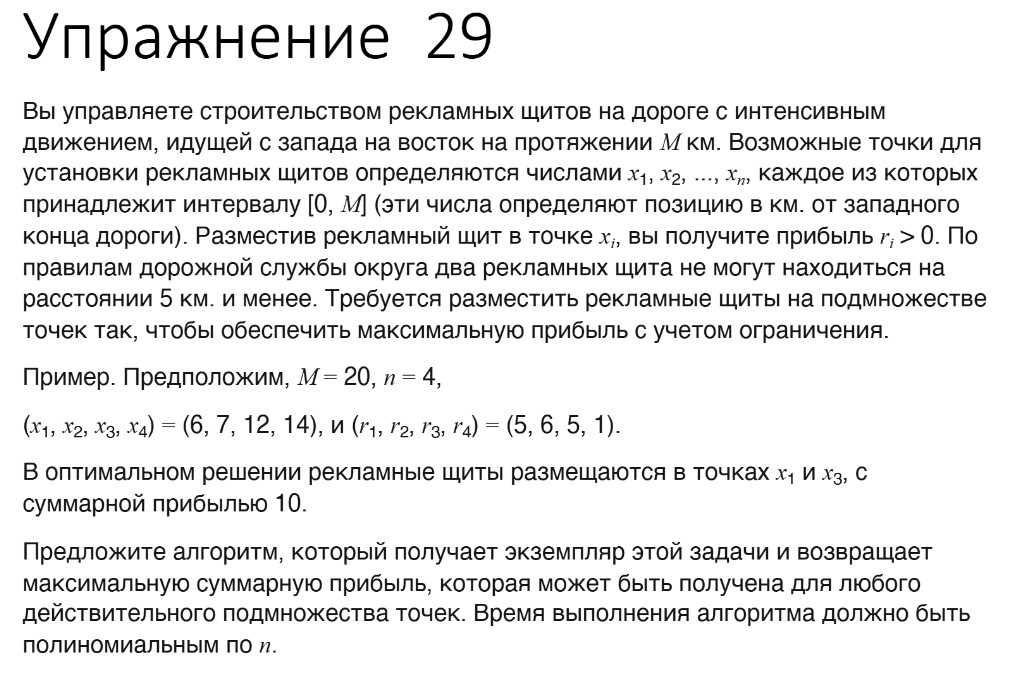

In [2]:
def max_profit(coords, profits, min_distance=5):
    """
    coords - координаты точек
    profits - прибыль в каждой точке
    min_distance - минимально допустимое расстояние между щитами
    Возвращает максимальную суммарную прибыль.
    """
    # Сортируем точки по координате вместе с прибылями
    paired = sorted(zip(coords, profits))
    sorted_coords = [p[0] for p in paired]
    sorted_profits = [p[1] for p in paired]
    n = len(sorted_coords)

    # last[i] — индекс последней точки, совместимой с i (или -1)
    last = [-1] * n
    for i in range(n):
        left, right = 0, i - 1
        best = -1
        while left <= right:
            mid = (left + right) // 2
            if sorted_coords[i] - sorted_coords[mid] > min_distance:
                best = mid
                left = mid + 1
            else:
                right = mid - 1
        last[i] = best

    # dp[i] — максимальная прибыль для первых i точек
    dp = [0] * (n + 1)
    for i in range(1, n + 1):
        take = sorted_profits[i-1]
        if last[i-1] != -1:
            take += dp[last[i-1] + 1]   # +1 из-за 0-индексации last
        skip = dp[i-1]
        dp[i] = max(take, skip)

    return dp[n]

if __name__ == "__main__":
    coords = [6, 7, 12, 14]
    profits = [5, 6, 5, 1]
    print(max_profit(coords, profits))

10


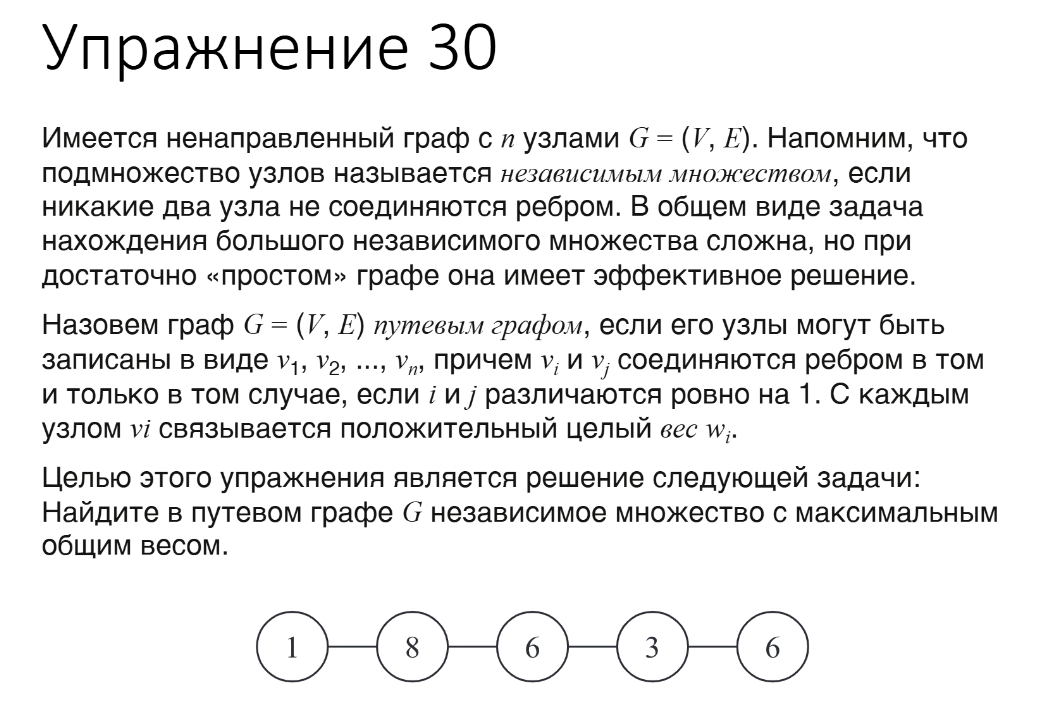

In [5]:
def max_weight_path(weights):
    """
    weights- список весов вершин пути (индексация с 0)
    возвращает максимальный суммарный вес независимого множества
    """
    n = len(weights)
    dp = [0] * (n + 1) # dp[0] = 0
    if n >= 1:
        dp[1] = weights[0]
    for i in range(2, n + 1):
        # i-1 — индекс в weights (0‑индексация)
        take = weights[i-1] + dp[i-2]
        skip = dp[i-1]
        dp[i] = max(take, skip)
    return dp[n]

print(max_weight_path([1, 8, 6, 3, 6]))

14


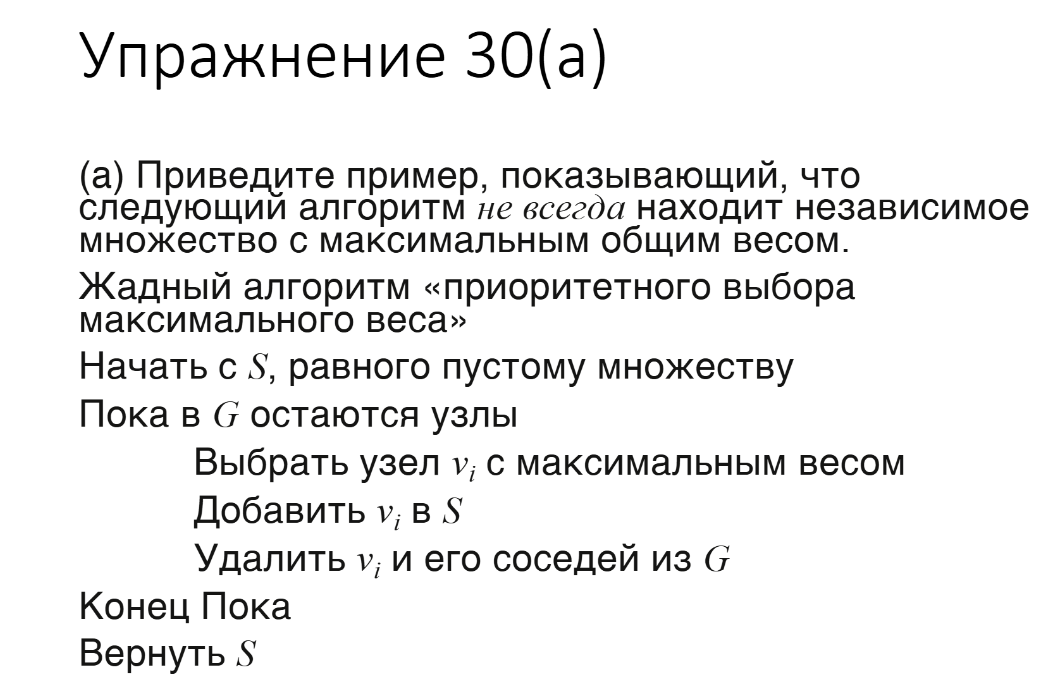

# **Контрпример для жадного алгоритма**

Вершины:   v1, v2, v3, v4, v5

Веса:   w1 = 3, w2 = 4, w3 = 3, w4 = 4, w5 = 3

**Пока остаются узлы выбираем вершину с самым большим весом, потом удаляем её и её соседей:**

1. Самый большой вес - 4. Таких вершин две: v2 и v4. Пусть алгоритм выберет v2.  
   Добавляем v2 в ответ, удаляем v2, а также её соседей v1 и v3.  
   Остаются только v4 и v5 (между ними ребро).

2. Теперь среди оставшихся максимальный вес 4 у вершины v4. Выбираем её, добавляем в ответ, удаляем v4 и её соседа v5.  
   Больше вершин нет.

Итог жадного алгоритма: выбраны вершины v2 и v4, сумма весов = 4 + 4 = 8.

**Оптимальное независимое множество:**  
Можно взять вершины v1, v3, v5. Они не соединены рёбрами, их сумма весов = 3 + 3 + 3 = 9.

# **Вывод:**  
Жадный алгоритм нашёл множество с весом 8, хотя существует множество с весом 9. Значит, этот жадный алгоритм не всегда находит максимальное по весу независимое множество в путевом графе.

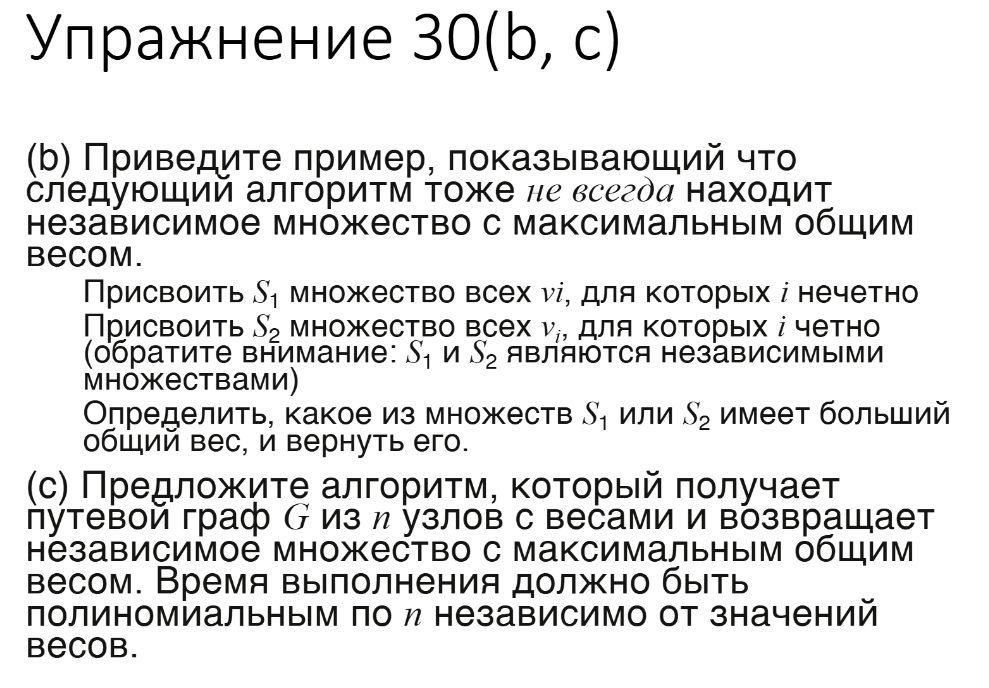

In [10]:
# 30(b)
weights = [2, 1, 2, 100]   # веса вершин v1, v2, v3, v4

S1 = weights[0] + weights[2]   # нечётные (v1 и v3)
S2 = weights[1] + weights[3]   # чётные (v2 и v4)

print("30(b)")
print("Веса:", weights)
print("Сумма на нечётных (v1+v3):", S1)
print("Сумма на чётных (v2+v4):", S2)
print("Алгоритм выберет:", max(S1, S2))
print("Но оптимальное независимое множество: v1 и v4, сумма =", weights[0] + weights[3])
print("Вывод: алгоритм неоптимален.\n")

# 30(с)
def max_weight_path(weights):
    n = len(weights)
    if n == 0:
        return 0
    if n == 1:
        return weights[0]
    dp = [0] * (n + 1)
    dp[1] = weights[0]
    for i in range(2, n + 1):
        dp[i] = max(dp[i-1], dp[i-2] + weights[i-1])
    return dp[n]

print("30(c)")
print("Оптимальный вес для [2,1,2,100]:", max_weight_path(weights))
print("Оптимальный вес для [1,8,6,3,6]:", max_weight_path([1, 8, 6, 3, 6]))

30(b)
Веса: [2, 1, 2, 100]
Сумма на нечётных (v1+v3): 4
Сумма на чётных (v2+v4): 101
Алгоритм выберет: 101
Но оптимальное независимое множество: v1 и v4, сумма = 102
Вывод: алгоритм неоптимален.

30(c)
Оптимальный вес для [2,1,2,100]: 102
Оптимальный вес для [1,8,6,3,6]: 14
